In [6]:
import pickle

emb_path = '/home/hbvision/Desktop/face-recognition/data/embeddings/hb-kor-latest.pkl'

with open(emb_path, 'rb') as f:
    data = pickle.load(f)

names = data['names']
embeddings = data['embeddings']

type(embeddings)

numpy.ndarray

In [11]:
import collections

names_to_embeddings = collections.defaultdict(list)

for name, embedding in zip(names, embeddings):
    real_name = name.split('_')[0]
    names_to_embeddings[real_name].append(embedding)

In [20]:
# For each name, we will take the mean of the embeddings
import numpy as np
def mean_embeddings(embeddings):
    return np.mean(embeddings, axis=0)
mean_embeddings_dict = {}
for name, embeddings in names_to_embeddings.items():
    mean_embeddings_dict[name] = mean_embeddings(embeddings)

# save the names and mean embeddings to pickle file as how it was loaded
emb_path = '/home/hbvision/Desktop/face-recognition/data/embeddings/hb-kor-mean.pkl'
with open(emb_path, 'wb') as f:
    pickle.dump({'names': list(mean_embeddings_dict.keys()), 'embeddings': list(mean_embeddings_dict.values())}, f)

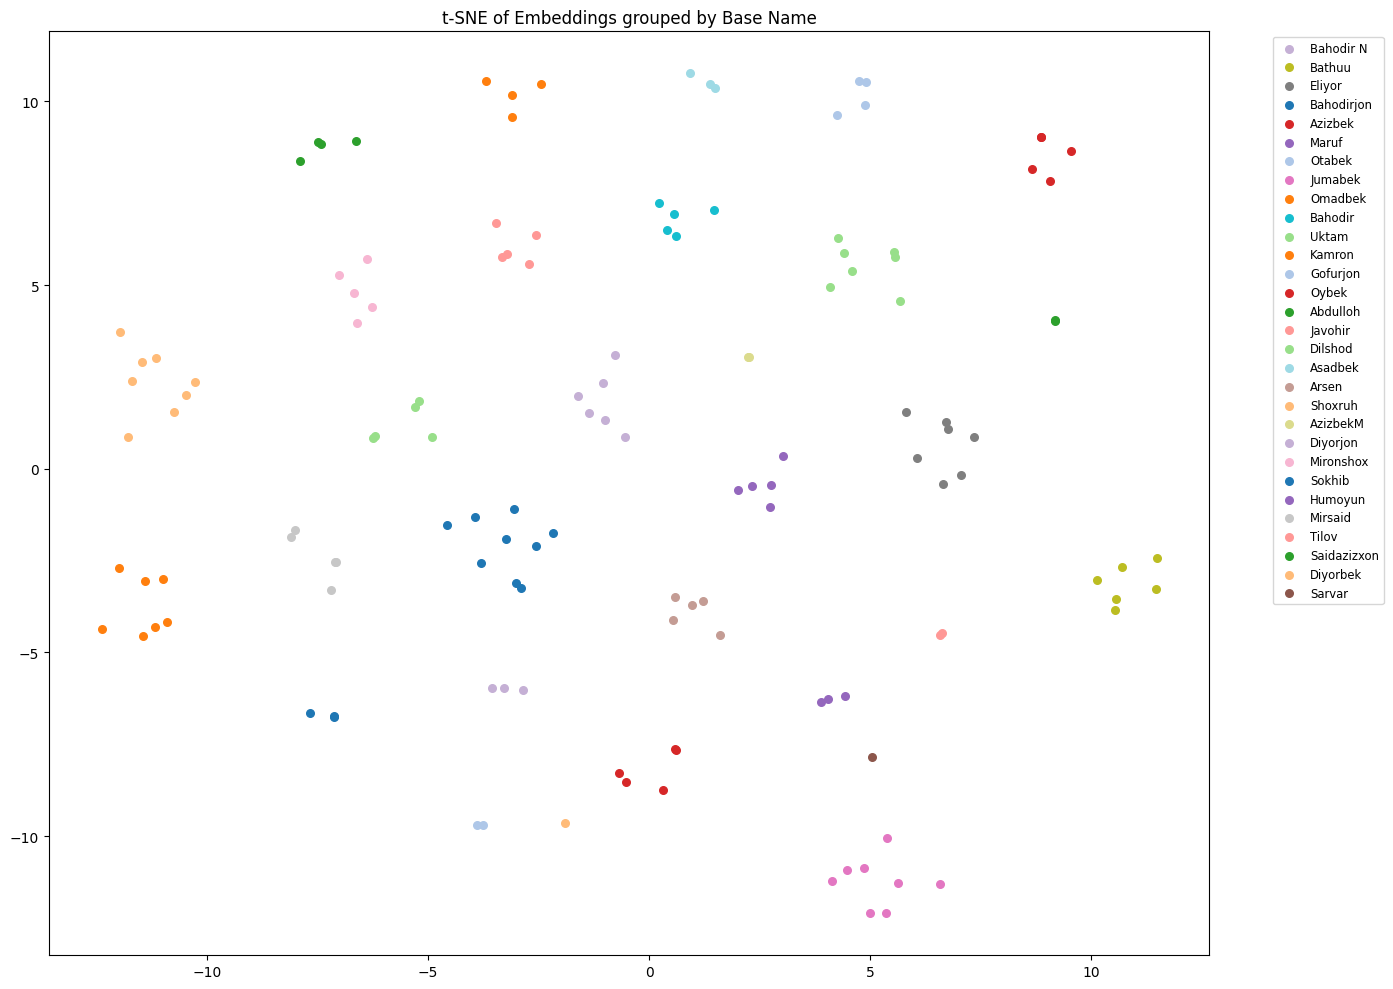

In [4]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np

# Step 1: Extract base names (before underscore or as-is)
base_names = [name.split('_')[0] for name in names]

# Step 2: Convert embeddings to numpy array
embeddings_np = np.array(embeddings)

# Step 3: Run t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
embeddings_2d = tsne.fit_transform(embeddings_np)

# Step 4: Plot with color coding per base name
plt.figure(figsize=(14, 10))
unique_labels = list(set(base_names))
label_to_color = {label: plt.cm.tab20(i % 20) for i, label in enumerate(unique_labels)}

for i, label in enumerate(base_names):
    x, y = embeddings_2d[i]
    plt.scatter(x, y, color=label_to_color[label], label=label if label not in plt.gca().get_legend_handles_labels()[1] else "", s=30)

plt.title("t-SNE of Embeddings grouped by Base Name")
plt.legend(loc='best', fontsize='small', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()
